# Jokes clustering and classification using SBERT

Antoine de Chabannes Curton la Palice, Hugo Viana

## Abstract

l'abstract ici

## 1. Introduction

L'intro ici

## 2. Materials and methods

Dependencies

In [1]:
# Data management libraries
import os
import numpy as np
import pandas as pd
import kagglehub

# Jokes embedding
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# Clustering algorithms
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 2.1. Dataset

Le dataset ici

In [2]:
path = kagglehub.dataset_download("abhinavmoudgil95/short-jokes")

df = pd.read_csv(os.path.join(path, "shortjokes.csv"))
print(df.head())

Using Colab cache for faster access to the 'short-jokes' dataset.
   ID                                               Joke
0   1  [me narrating a documentary about narrators] "...
1   2  Telling my daughter garlic is good for you. Go...
2   3  I've been going through a really rough period ...
3   4  If I could have dinner with anyone, dead or al...
4   5     Two guys walk into a bar. The third guy ducks.


In [3]:
##################################################
########## A RETIRER !!!!!! ######################
##################################################
df = df.head(10000)

### 2.2. Jokes embedding

Embedding avec SBERT

In [4]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

df["embedding"] = df["Joke"].apply(lambda x: np.array(model.encode(x)))

print(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   ID                                               Joke  \
0   1  [me narrating a documentary about narrators] "...   
1   2  Telling my daughter garlic is good for you. Go...   
2   3  I've been going through a really rough period ...   
3   4  If I could have dinner with anyone, dead or al...   
4   5     Two guys walk into a bar. The third guy ducks.   

                                           embedding  
0  [-0.0019190103, -0.04273604, -0.017304454, -0....  
1  [-0.07587159, 0.06581424, 0.006111781, 0.06642...  
2  [-0.094529964, -0.031642836, 0.091890045, 0.05...  
3  [-0.077876724, 0.023547389, -0.10157586, 0.007...  
4  [0.04891309, -0.086067915, -0.041825227, -0.04...  


### 2.3. Clustering

1. Choix du nombre de clusters
2. Choix de l'algo (K-Means)
3. Evaluation et Interprétati

#### Optimisation of the number of clusters

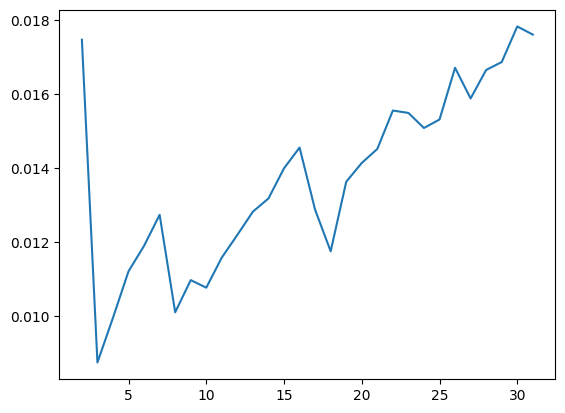

In [10]:
# Determine the optimal number of clusters using the Elbow method
wcss = []
silouette_score = []
for i in range(2, 32):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df["embedding"].tolist())
    wcss.append(kmeans.inertia_)
    silouette_score.append(silhouette_score(df["embedding"].tolist(), kmeans.labels_))



# Plot the Elbow method
import matplotlib.pyplot as plt
plt.plot(range(2, 32), silouette_score)
# plt.plot(range(2, 12), wcss)
# plt.title('Elbow Method')
# plt.xlabel('Number of clusters')
# plt.ylabel('WCSS')  # Within-cluster sum of squares
plt.show()


#### Generating clusters

#### Evaluation of the performance and selection of the best method

### 2.4. Classification




1.   Labelisation des données avec les clusters extraits
2.   modèle de classification
3.   optimisation des paramètres
4.   entrainement du modèle



## 3. Results

Résultats du clustering, quels types de blagues ressortent ?
Performances de la classification

### 3.1 Clustering

Résultats du clustering, quels types de blagues ressortent ?

### 3.2. Classification

Performance du modèle de classification

## 4. Discussion

La conclusion plus ou moins

## 5. Future works

Perspectives futures

## References

1.   Abhinav Moudgil. **Short Jokes**. https://www.kaggle.com/datasets/abhinavmoudgil95/short-jokes
2.   Nils Reimers, Iryna Gurevych. **Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks**. Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing, 2019. https://arxiv.org/abs/1908.10084
3.   Alina Petukhovaa, João P. Matos-Carvalhoa, Nuno Fachada. **Text clustering with LLM embeddings**. International Journal of Cognitive Computing in Engineering, Volume 6, 2025. https://doi.org/10.1016/j.ijcce.2024.11.004

